# Prédire les crises d'épilepsie à partir de l'ECG
**Projet DESU Data Science - Alina Titova**

**Tuteur : Nicolas Rochet**

Dataset : [SeizeIT2 — OpenNeuro ds005873](https://openneuro.org/datasets/ds005873/versions/1.1.0)

In [1]:
# Tout d'abord on import les librairies nécessaires

import pandas as pd
import numpy as np
import mne
import sklearn 
import matplotlib.pyplot as plt
import os 
import glob
import random

# Dossier qui contient tous les patients (sub-001, sub-002, etc.)
DOSSIER_DATA = r"C:\Users\Alina\Desktop\AMU\DESU Data science\Projet\Data"

In [ ]:
# Ici on définit quelques fonctions pour manipuler les fichiers EEG et ECG des patients.
# ECG est le coeur pour les prédictions, mais il est stocké dans un dossier séparé du dossier EEG. On va donc relier les deux.

# Cette fonction permet de trouver  le dossier spécifique à l'autre niveau.
def dossier_eeg(patient):
    """Donne le chemin du dossier eeg d'un patient. Exemple : dossier_eeg("sub-100")"""
    return os.path.join(DOSSIER_DATA, patient, "ses-01", "eeg")

# Cette fonction permet de lister toutes les crises d'un patient. Car les crises sont listées dans les fichiers *_events.tsv du dossier eeg.
def liste_crises(patient):
    """Lit tous les fichiers .tsv du patient et renvoie un tableau de TOUTES ses crises."""
    fichiers_tsv = sorted(glob.glob(os.path.join(dossier_eeg(patient), "*_events.tsv"))) 
    # La fonction glob.glob() permet de lister tous les fichiers qui correspondent à un motif donné. Ici, on cherche tous les fichiers qui se terminent par "_events.tsv" dans le dossier eeg du patient.

    toutes_les_crises = []
    for fichier in fichiers_tsv:
        tableau = pd.read_csv(fichier, sep="\t")
        crises = tableau[tableau["eventType"].str.startswith("sz", na=False)]
        for _, ligne in crises.iterrows():
            toutes_les_crises.append({
                "fichier_tsv": fichier,
                "debut": ligne["onset"],
                "duree": ligne["duration"],
                "type": ligne["eventType"],
            })
    return pd.DataFrame(toutes_les_crises)


# Après avoir trouvé les crises, on va chercher le fichier ECG correspondant à la même run. Car le fichier ECG est stocké dans un dossier séparé du dossier EEG.
def fichier_ecg(fichier_tsv):
    """À partir du .tsv (dossier eeg), trouve le fichier ECG de la même run (dossier ecg)."""
    chemin = fichier_tsv.replace(os.sep + "eeg" + os.sep, os.sep + "ecg" + os.sep)
    return chemin.replace("_events.tsv", "_ecg.edf")


# Cette fonction permet de charger un morceau d'ECG entre deux temps donnés (en secondes). On utilise la librairie MNE pour lire les fichiers EDF.
def charger_ecg(chemin_ecg, debut, fin):
    """Charge seulement le morceau d'ECG entre 'debut' et 'fin' (en secondes)."""
    raw = mne.io.read_raw_edf(chemin_ecg, preload=False, verbose="ERROR") # preload=False pour ne pas charger tout le fichier en mémoire, juste les métadonnées. verbose="ERROR" pour ne pas afficher les warnings.
    canal = raw.ch_names[0]                                               # le fichier ECG n'a qu'un canal : "ECG SD"
    debut = max(0, debut)                                                 # pas avant le début de l'enregistrement
    fin = min(raw.times[-1], fin)                                         # pas après la fin
    morceau = raw.copy().pick([canal]).crop(tmin=debut, tmax=fin).load_data()
    signal, temps = morceau[:]                                            # MNE renvoie un tableau 2D (canaux x temps) et un tableau 1D (temps). Ici on n'a qu'un canal, donc signal est 2D avec une seule ligne.
    return temps + debut, signal[0], canal                                # on remet le vrai temps


def tracer_crise(patient, numero=0, marge=30):
    """Trace l'ECG autour d'une crise du patient, avec la crise en rouge."""
    crises = liste_crises(patient)
    if len(crises) == 0:
        print("Aucune crise chez", patient)
        return
    if numero >= len(crises):
        print(f"{patient} n'a que {len(crises)} crise(s). Choisissez un numéro entre 0 et {len(crises)-1}.")
        return

    crise = crises.iloc[numero]               # iloc pour accéder à la ligne du DataFrame correspondant à la crise numéro 'numero'
    chemin = fichier_ecg(crise["fichier_tsv"])
    if not os.path.exists(chemin):
        print("Pas de fichier ECG pour cette run :", chemin)
        return

    debut, duree = crise["debut"], crise["duree"]
    temps, signal, canal = charger_ecg(chemin, debut - marge, debut + duree + marge)

    plt.figure(figsize=(14, 4))
    plt.plot(temps, signal, linewidth=0.6, color="black")
    plt.axvspan(debut, debut + duree, color="red", alpha=0.3, label="Crise")
    plt.xlabel("Temps (s)")
    plt.ylabel(canal)
    plt.title(f"{patient} — crise {numero+1}/{len(crises)} — {os.path.basename(chemin)}")
    plt.legend()
    plt.show()

                                         fichier_tsv  debut  duree  \
0  C:\Users\Alina\Desktop\AMU\DESU Data science\P...  111.0   82.0   
1  C:\Users\Alina\Desktop\AMU\DESU Data science\P...  240.0   42.0   
2  C:\Users\Alina\Desktop\AMU\DESU Data science\P...  269.0   51.0   
3  C:\Users\Alina\Desktop\AMU\DESU Data science\P...  284.0   86.0   
4  C:\Users\Alina\Desktop\AMU\DESU Data science\P...  294.0   24.0   

           type  
0  sz_foc_ia_um  
1  sz_foc_ia_um  
2  sz_foc_ia_um  
3  sz_foc_ia_um  
4  sz_foc_ia_um  
Reading 0 ... 72192  =      0.000 ...   282.000 secs...


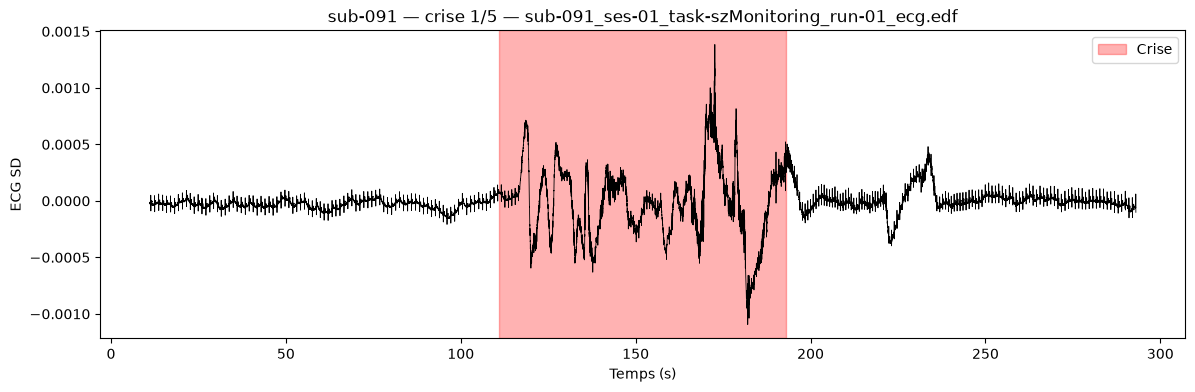

Reading 0 ... 61952  =      0.000 ...   242.000 secs...


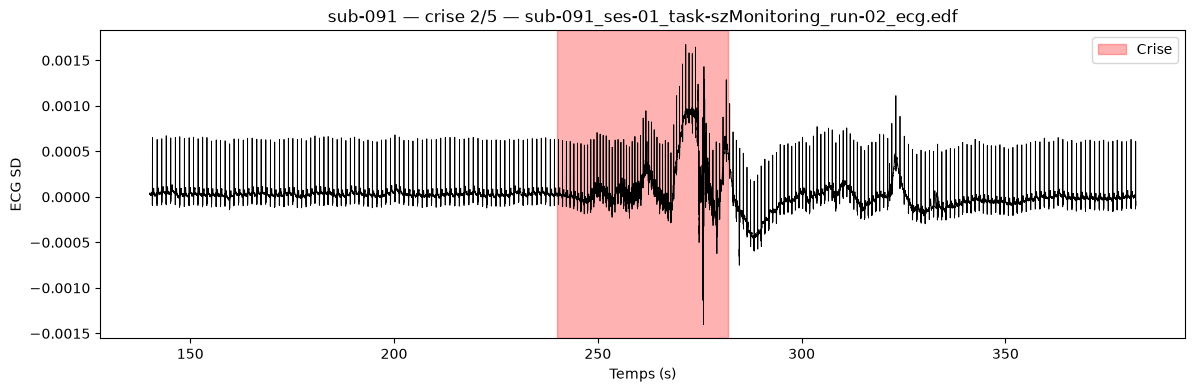

Reading 0 ... 84736  =      0.000 ...   331.000 secs...


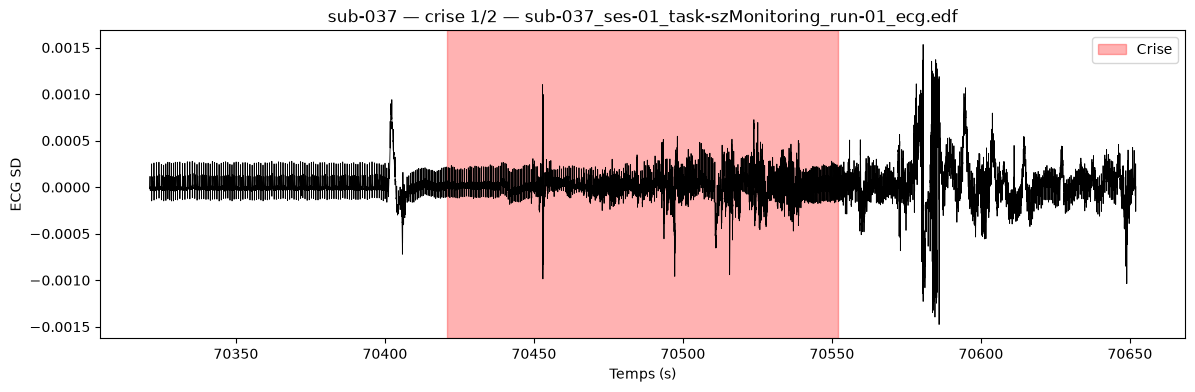

In [18]:
# Voir toutes les crises d'un patient
crises = liste_crises("sub-091")
print(crises)

# Tracer la 1re crise
tracer_crise("sub-091", marge=100)

# Tracer la 2e crise (on compte à partir de 0)
tracer_crise("sub-091", numero=1, marge=100)

# Un autre patient, avec plus de marge
tracer_crise("sub-037", numero=0, marge=100)